---
## This plot will recreate  "Figure 1" for the paper draft of Jun. '26, but...
### ...adding robustness check(s) on the zonal means, PLUS using HI and Tw instead of T and Td
##### Noel Siegert, 6/30/26
---

In [1]:
# kernel: pangeo23

In [2]:
# imports
import os
import xarray as xr
import numpy as np
import netCDF4 
import glob
import pandas as pd
import geopandas as gpd
from datetime import datetime
from scipy import stats
from scipy.spatial import cKDTree

from coastal_analysis_fns import *

In [3]:
# interactive plotting stuff 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.lines import Line2D 

#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

In [4]:
script = 'FigS6_resubmissionJun26-CopyFig1WithHIandTw.ipynb'

In [5]:
def compute_density_weights(lats, lons, radius_deg=5.0):
    """
    Inverse density weights for stations within a latitude band.
    Uses KD-tree to count neighbors within radius_deg.

    inputs: list of lats, lons, and radius (in ˚) for which to look for neighbors. depends on what spatial scale you think is important
    """
    # Approximate planar distance in degrees (fine within a narrow lat band)
    coords = np.column_stack([lats, lons])
    tree = cKDTree(coords)
    
    # Count neighbors within radius (incl. self)
    neighbor_counts = np.array([len(tree.query_ball_point(pt, radius_deg)) for pt in coords])
    
    weights = 1.0 / neighbor_counts
    
    return weights / weights.sum()  # normalize to sum to 1

In [6]:
def bin_lat_scatters_densitywtd_bootCI(latbins, lats, lons, dat, nboot, radius_deg):
    '''
    like bin_lat_scatters, but within each lat-bin I'm doing nboot bootstrapped means 
        (sampled with replacement) and weighted by inverse of station density (to try to
        counteract the effect of station spatial clustering/autocorrelation on the lat-bin-mean)

    new input params: lons, nboot, radius_deg (what the density radius of autocorr. is that you care about    
    
    returns: median, 97.5, and 2.5 %ile estimates for bootstrapped means, the entire array of 1k bootstrap iterations, bin midpoints, and bin num. obs. 

    6/18/26
    '''

    # random seed
    rng = np.random.default_rng(27)

    # empty arrays to hold output
    binned_boots = np.zeros(shape=(len(latbins)-1, nboot)) * np.nan # dims = [lat_bin, bootstrap_mean_draw]
    bin_midpoints = np.zeros(len(latbins)-1)
    bin_n_obs = np.zeros(len(latbins)-1)
    
    i = 0
    
    no_inf_mask = np.logical_not(np.isinf(dat)) # 5/9

    # for each lat bin
    while i < len(latbins)-1:

        # sel lat bin bounds, generate bin mask
        bot_bin = latbins[i]
        top_bin = latbins[i+1]
        binmask = (lats >= bot_bin) * (lats < top_bin)

#        print(i, bot_bin, top_bin)

        # skip bin if there are no obs in that bin
        if np.sum(binmask) == 0:
#            print('skip this bin.')
            bin_midpoints[i] = ((bot_bin+top_bin)/2)
            bin_n_obs[i] = 0
            i += 1
            continue

        # set vals to send to bootstrap
        dat_bin = dat[binmask]
        lats_bin = lats[binmask]
        lons_bin = lons[binmask]

        # distance-weights for this lat bin
        weights = compute_density_weights(lats=lats_bin, lons=lons_bin, radius_deg=radius_deg)

        # empty array to store bootstrap draws
        boot_stats = (np.zeros(nboot) * np.nan)

        # do the bootstrapped mean
        for b in range(nboot):
            idx = rng.choice(len(dat_bin), size=len(dat_bin), replace=True, p=weights)
            boot_stats[b] = np.nanmean(dat_bin[idx]) # don't think I need nanmean

        # add the results to the output arrays
        binned_boots[i, :] = boot_stats
        bin_midpoints[i] = ((bot_bin+top_bin)/2)
        bin_n_obs[i] = np.sum(binmask)

        # update counter var
        i += 1


    
    return np.quantile(binned_boots, 0.5, axis=1), np.quantile(binned_boots, 0.975, axis=1), np.quantile(binned_boots, 0.025, axis=1), binned_boots, bin_midpoints, bin_n_obs

In [7]:
# dataframe with the stations we are using
df = pd.read_csv('/home/nsiegert/projects/coastal_sst/data/hadisd_stations_using_Expanded.csv')
df = df.drop(['Unnamed: 0'], axis=1)

# convert df into geodataframe for ease of plotting
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(x=df.LON, y=df.LAT))

In [8]:
# open geophysical data

# MHW
hw_ds = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.1.5deg.marineheatwaves_roll11.nc') # 11 DAY ROLLING!!!
mhw_mask = hw_ds.MHW.data.astype(bool)

# station var's
HI_det_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.HI.detrend_anom.roll11.nc').HI # note new filename 6/30
Tw_det_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.Tw.detrend_anom.roll11.nc').Tw # note new filename 6/30

# tmean (raw)
tx_raw_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.tx.nc').Tx
tn_raw_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.tn.nc').Tn
tmean_da = (tx_raw_da + tn_raw_da) / 2

# raw Tw
Tw_raw_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.Tw.nc').Tw

# raw HI
HI_raw_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.HI.nc').HI

# SST 
sst_da = xr.open_dataset('/dx02/data/nsiegert/oisst_station_cirleavg/ALLSTATIONS.1.5deg.daily.sst.1.9.2025.nc').sst.sel(time=slice('1990-01-01', '2023-12-31'))
sst_det_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.sst.detrend_anom.roll11.nc').sst.sel(time=slice('1990-01-01', '2023-12-31')) # note new filename 11/21

# season masks
szn_ds = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.warm_cold_seasons.nc')
warmszn_mask = szn_ds.warmszn_mask.astype(bool)
coldszn_mask = szn_ds.coldszn_mask.astype(bool)

# Analysis

In [9]:
## average HI and Tw anom's during coastal MHW days 


# create MHW composites of important var's and add to gdf so we can plot

# station-mean (detrended anom) HI for MHW days and all days, for all szn, cold szn, and warm szn
gdf['HI_det_mean'] = HI_det_da.mean(dim='time')
gdf['HI_det_mean_w'] = HI_det_da.where(warmszn_mask).mean(dim='time')
gdf['HI_det_mean_c'] = HI_det_da.where(coldszn_mask).mean(dim='time')
gdf['HI_det_mhw_mean'] = HI_det_da.where(mhw_mask).mean(dim='time')
gdf['HI_det_mhw_mean_w'] = HI_det_da.where(mhw_mask*warmszn_mask).mean(dim='time')
gdf['HI_det_mhw_mean_c'] = HI_det_da.where(mhw_mask*coldszn_mask).mean(dim='time')

# station-mean (detrended anom) Dewpoint for MHW days and all days, for all szn, cold szn, and warm szn
gdf['Tw_det_mean'] = Tw_det_da.mean(dim='time')
gdf['Tw_det_mean_w'] = Tw_det_da.where(warmszn_mask).mean(dim='time')
gdf['Tw_det_mean_c'] = Tw_det_da.where(coldszn_mask).mean(dim='time')
gdf['Tw_det_mhw_mean'] = Tw_det_da.where(mhw_mask).mean(dim='time')
gdf['Tw_det_mhw_mean_w'] = Tw_det_da.where(mhw_mask*warmszn_mask).mean(dim='time')
gdf['Tw_det_mhw_mean_c'] = Tw_det_da.where(mhw_mask*coldszn_mask).mean(dim='time')

In [10]:
# binned lat profiles of HI and Tw and tn
HI_det_mhw_binned, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 3), lats=gdf['LAT'].to_numpy(), dat=gdf['HI_det_mhw_mean'].to_numpy())
HI_det_mhw_binned_w, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 3), lats=gdf['LAT'].to_numpy(), dat=gdf['HI_det_mhw_mean_w'].to_numpy())
HI_det_mhw_binned_c, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 3), lats=gdf['LAT'].to_numpy(), dat=gdf['HI_det_mhw_mean_c'].to_numpy())

tw_det_mhw_binned, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 3), lats=gdf['LAT'].to_numpy(), dat=gdf['Tw_det_mhw_mean'].to_numpy())
tw_det_mhw_binned_w, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 3), lats=gdf['LAT'].to_numpy(), dat=gdf['Tw_det_mhw_mean_w'].to_numpy())
tw_det_mhw_binned_c, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 3), lats=gdf['LAT'].to_numpy(), dat=gdf['Tw_det_mhw_mean_c'].to_numpy())

/home/nsiegert/projects/coastal_sst/code/analysis/coastal_analysis_fns.py:53: RuntimeWarning: Mean of empty slice
  binned_means.append(np.nanmean(dat[binmask*no_inf_mask]))


In [11]:
%%time
# binned lat profiles of HI and tw - this time using the density-weighted bootstrap resampling within each bin. 
# a 3˚ bin sorta seems to be where the CI's stabilize...
HI_mhw_w_binboot_med, HI_mhw_w_binboot_hi, HI_mhw_w_binboot_lo, HI_mhw_binboots_w, bin_midpoints, \
    bin_nobs = bin_lat_scatters_densitywtd_bootCI(latbins=np.arange(-60, 71, 3), 
                                                          lats=gdf['LAT'].to_numpy(), lons=gdf['LON'].to_numpy(), 
                                                          dat=gdf['HI_det_mhw_mean_w'].to_numpy(), nboot=1000, radius_deg=3.0)

HI_mhw_c_binboot_med, HI_mhw_c_binboot_hi, HI_mhw_c_binboot_lo, HI_mhw_binboots_c, bin_midpoints, \
    bin_nobs = bin_lat_scatters_densitywtd_bootCI(latbins=np.arange(-60, 71, 3), 
                                                          lats=gdf['LAT'].to_numpy(), lons=gdf['LON'].to_numpy(), 
                                                          dat=gdf['HI_det_mhw_mean_c'].to_numpy(), nboot=1000, radius_deg=3.0)


tw_mhw_w_binboot_med, tw_mhw_w_binboot_hi, tw_mhw_w_binboot_lo, tw_mhw_binboots_w, bin_midpoints, \
    bin_nobs = bin_lat_scatters_densitywtd_bootCI(latbins=np.arange(-60, 71, 3), 
                                                          lats=gdf['LAT'].to_numpy(), lons=gdf['LON'].to_numpy(), 
                                                          dat=gdf['Tw_det_mhw_mean_w'].to_numpy(), nboot=1000, radius_deg=3.0)

tw_mhw_c_binboot_med, tw_mhw_c_binboot_hi, tw_mhw_c_binboot_lo, tw_mhw_binboots_c, bin_midpoints, \
    bin_nobs = bin_lat_scatters_densitywtd_bootCI(latbins=np.arange(-60, 71, 3), 
                                                          lats=gdf['LAT'].to_numpy(), lons=gdf['LON'].to_numpy(), 
                                                          dat=gdf['Tw_det_mhw_mean_c'].to_numpy(), nboot=1000, radius_deg=3.0)

CPU times: user 10.8 s, sys: 11.8 ms, total: 10.8 s
Wall time: 10.8 s


## For every coastal SST decile (bin), what is the frequency of being in < Var > threshold?

In [12]:
# generate mask for terrestrial HI, tw, and HI < 10th percentile
hh = HI_raw_da.groupby("time.dayofyear").quantile(0.1)
HI10_mask = HI_raw_da.groupby("time.dayofyear") <= hh

hk = Tw_raw_da.groupby("time.dayofyear").quantile(0.1)
tw10_mask = Tw_raw_da.groupby("time.dayofyear") <= hk

# generate mask for terrestrial HI, tw > 90th percentile
hh = HI_raw_da.groupby("time.dayofyear").quantile(0.9)
HI90_mask = HI_raw_da.groupby("time.dayofyear") > hh

hk = Tw_raw_da.groupby("time.dayofyear").quantile(0.9)
tw90_mask = Tw_raw_da.groupby("time.dayofyear") > hk

In [13]:
%%time
# compute these curves for each station individually (that's what's happening in this cell)

## embarrassingly parallelizeable code... (takes ~1 min)

print('starting')
sstbins = np.arange(0, 1.1, 0.1)

# arrays to hold output
sstbinned_HI90_all = np.zeros(shape=(10, len(gdf))) # row = sst bin, col = each unique station
sstbinned_HI90_w = np.zeros(shape=(10, len(gdf))) 
sstbinned_HI90_c = np.zeros(shape=(10, len(gdf))) 
sstbinned_HI10_all = np.zeros(shape=(10, len(gdf)))
sstbinned_HI10_w = np.zeros(shape=(10, len(gdf)))
sstbinned_HI10_c = np.zeros(shape=(10, len(gdf)))

sstbinned_tw90_all = np.zeros(shape=(10, len(gdf))) # row = sst bin, col = each unique station
sstbinned_tw90_w = np.zeros(shape=(10, len(gdf))) 
sstbinned_tw90_c = np.zeros(shape=(10, len(gdf))) 
sstbinned_tw10_all = np.zeros(shape=(10, len(gdf)))
sstbinned_tw10_w = np.zeros(shape=(10, len(gdf)))
sstbinned_tw10_c = np.zeros(shape=(10, len(gdf)))

# for each bin
for i in range(10):
    
    # quantiles for bin edges
    lo = sstbins[i]
    hi = sstbins[i+1]
    print(i, sstbins[i], sstbins[i+1])
    
    # generate mask for SST falling within that quantile range
    loqtiles = sst_da.groupby("time.dayofyear").quantile(sstbins[i])
    hiqtiles = sst_da.groupby("time.dayofyear").quantile(sstbins[i+1])
    sst_bin_mask = (sst_da.groupby("time.dayofyear") >= loqtiles) * (sst_da.groupby("time.dayofyear") < hiqtiles)
    
    # WITHIN THAT SST BIN: compute frequequency of exceeding HI 90th %ile or being lower than HI 10th %ile (also for warm and cold seasons)
    sstbinned_HI90_all[i,:] = HI90_mask.where(sst_bin_mask).mean(dim='time').data
    sstbinned_HI90_w[i,:] = HI90_mask.where(sst_bin_mask*warmszn_mask).mean(dim='time').data
    sstbinned_HI90_c[i,:] = HI90_mask.where(sst_bin_mask*coldszn_mask).mean(dim='time').data

    sstbinned_HI10_all[i,:] = HI10_mask.where(sst_bin_mask).mean(dim='time').data
    sstbinned_HI10_w[i,:] = HI10_mask.where(sst_bin_mask*warmszn_mask).mean(dim='time').data
    sstbinned_HI10_c[i,:] = HI10_mask.where(sst_bin_mask*coldszn_mask).mean(dim='time').data
    
    # ALSO WITHIN THAT SST BIN: compute frequequency of exceeding Tw 90th %ile or being lower than Tw 10th %ile (also for warm and cold seasons)
    sstbinned_tw90_all[i,:] = tw90_mask.where(sst_bin_mask).mean(dim='time').data
    sstbinned_tw90_w[i,:] = tw90_mask.where(sst_bin_mask*warmszn_mask).mean(dim='time').data
    sstbinned_tw90_c[i,:] = tw90_mask.where(sst_bin_mask*coldszn_mask).mean(dim='time').data
    
    sstbinned_tw10_all[i,:] = tw10_mask.where(sst_bin_mask).mean(dim='time').data
    sstbinned_tw10_w[i,:] = tw10_mask.where(sst_bin_mask*warmszn_mask).mean(dim='time').data
    sstbinned_tw10_c[i,:] = tw10_mask.where(sst_bin_mask*coldszn_mask).mean(dim='time').data

print('done')

starting
0 0.0 0.1
1 0.1 0.2
2 0.2 0.30000000000000004
3 0.30000000000000004 0.4
4 0.4 0.5
5 0.5 0.6000000000000001
6 0.6000000000000001 0.7000000000000001
7 0.7000000000000001 0.8
8 0.8 0.9
9 0.9 1.0
done
CPU times: user 6min 53s, sys: 26.1 s, total: 7min 19s
Wall time: 54.9 s


In [14]:
## Generate regionally stratified bootstrapped global means and CI's (what's happening in this cell)

# for every coastal SST decile bin AND 3˚ latitude bin, I will get 1k bootstrapped mean values for the frequency of <var> > 90%ile.
    # then, I will area-weight-average the lat-bins together to get 1k globally stratified-resampled bootstrap means for 
            #[frequency of <var> in 90%ile given the coastal SST decile]
    # then, I can take the median and 95% CI of those 1k global bootstrapped means. 

# generate land-area weights based on lat-bin width
wts = np.cos(np.deg2rad(bin_midpoints))
wts_da = xr.DataArray(wts, dims=['binlat'], coords={'binlat':bin_midpoints})

# empty arrays to hold outputs
sstbinned_HI90_bootmeds_w = np.zeros(10) * np.nan
sstbinned_HI90_hicis_w = np.zeros(10) * np.nan
sstbinned_HI90_locis_w = np.zeros(10) * np.nan 

sstbinned_tw90_bootmeds_w = np.zeros(10) * np.nan
sstbinned_tw90_hicis_w = np.zeros(10) * np.nan
sstbinned_tw90_locis_w = np.zeros(10) * np.nan 

sstbinned_HI90_bootmeds_c = np.zeros(10) * np.nan
sstbinned_HI90_hicis_c = np.zeros(10) * np.nan
sstbinned_HI90_locis_c = np.zeros(10) * np.nan 

sstbinned_tw90_bootmeds_c = np.zeros(10) * np.nan
sstbinned_tw90_hicis_c = np.zeros(10) * np.nan
sstbinned_tw90_locis_c = np.zeros(10) * np.nan 


# for each SST bin (quantiles 0-10)
for i in range(10):

    print('sst bin: {}'.format(i))

    # for outcome var = HI>90%ile and tw>90%ile in both warm and cold seasons
    for j, in_var in enumerate([sstbinned_HI90_w[i,:], sstbinned_tw90_w[i,:], sstbinned_HI90_c[i,:], sstbinned_tw90_c[i,:]]):
    
        ## do the binning
        # do a global bootstrap resampling for that SST bin (don't want the medians and ci's for this so will name the fn. ouptut as irrelevant things)
        aa, bb, cc, sstbinned_var90_w_allboots, \
            bin_midpoints, bin_nobs = bin_lat_scatters_densitywtd_bootCI(latbins=np.arange(-60, 71, 3), 
                                                              lats=gdf['LAT'].to_numpy(), lons=gdf['LON'].to_numpy(), 
                                                              dat=in_var, nboot=1000, radius_deg=3.0)
    
        # put into xarray dataArray b/c it's easier for me to take weighted means and ignore Nan's
        da = xr.DataArray(sstbinned_var90_w_allboots, dims=['binlat', 'boot'], coords={'binlat':bin_midpoints, 'boot':np.array(range(0, 1000))})
    
        # take area-weighted mean, now generating 1000 region-stratified bootstrapped means, from which to draw 95% CI
        global_boot_means = da.weighted(wts_da).mean(dim='binlat')
    
        # now get medians and 95% CI
        if j==0:
            sstbinned_HI90_bootmeds_w[i] = np.quantile(global_boot_means, 0.5)
            sstbinned_HI90_hicis_w[i] = np.quantile(global_boot_means, 0.975)
            sstbinned_HI90_locis_w[i] = np.quantile(global_boot_means, 0.025)
        elif j==1:
            sstbinned_tw90_bootmeds_w[i] = np.quantile(global_boot_means, 0.5)
            sstbinned_tw90_hicis_w[i] = np.quantile(global_boot_means, 0.975)
            sstbinned_tw90_locis_w[i] = np.quantile(global_boot_means, 0.025)
        elif j==2:
            sstbinned_HI90_bootmeds_c[i] = np.quantile(global_boot_means, 0.5)
            sstbinned_HI90_hicis_c[i] = np.quantile(global_boot_means, 0.975)
            sstbinned_HI90_locis_c[i] = np.quantile(global_boot_means, 0.025)
        elif j==3:
            sstbinned_tw90_bootmeds_c[i] = np.quantile(global_boot_means, 0.5)
            sstbinned_tw90_hicis_c[i] = np.quantile(global_boot_means, 0.975)
            sstbinned_tw90_locis_c[i] = np.quantile(global_boot_means, 0.025)

sst bin: 0
sst bin: 1
sst bin: 2
sst bin: 3
sst bin: 4
sst bin: 5
sst bin: 6
sst bin: 7
sst bin: 8
sst bin: 9


# plot

### HI and Tw Anomalies during coastal MHW conditions

Like the fig. from 2/26 but using HI and Tw


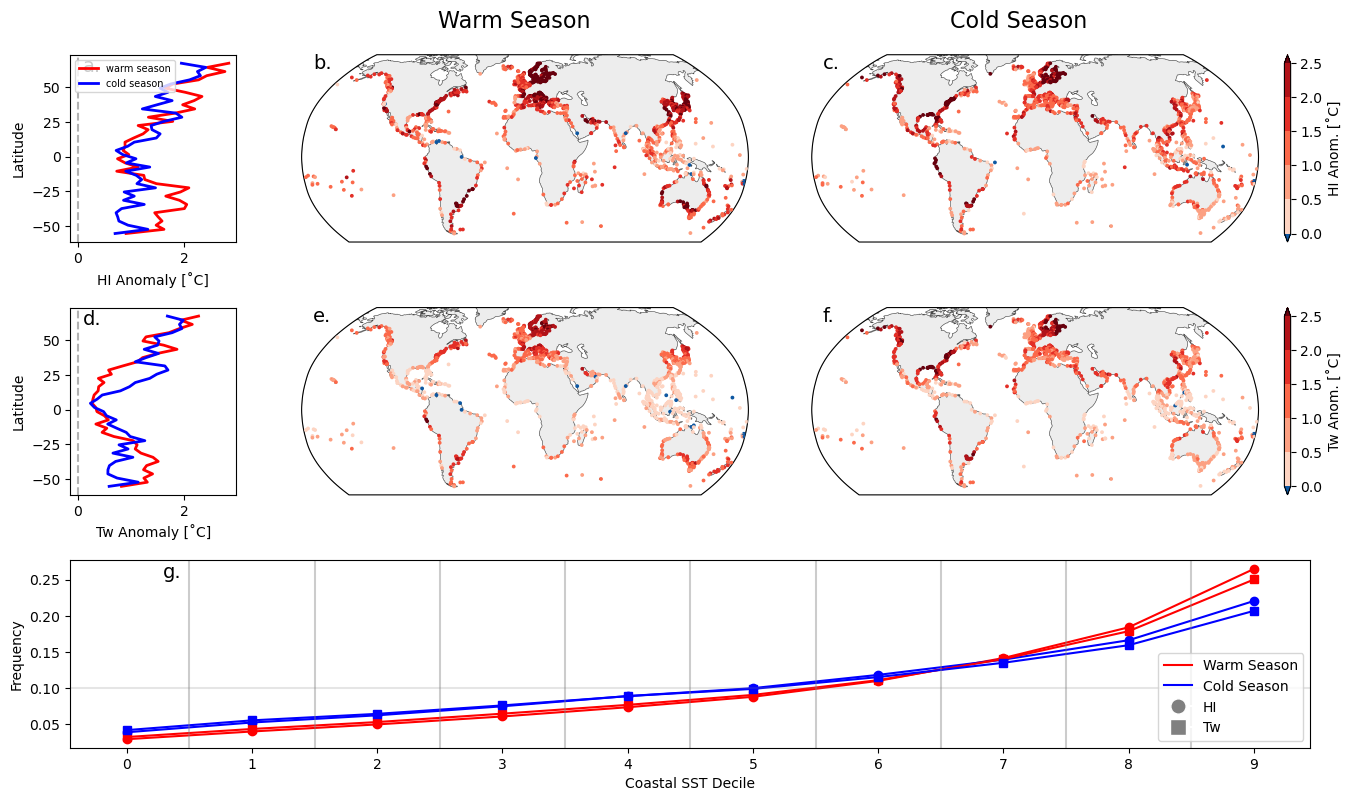

In [15]:
# make the plot -- THIS IS THE VERSION FROM PAPER SUBMISSION 2/2026

# set cmap
vmin = 0
vmax = 2.5
ncol_i = 6
bounds_i = np.linspace(vmin, vmax, ncol_i)
bluecolors = plt.get_cmap('Blues')(np.linspace(0,1,21))
cols = plt.get_cmap('Reds')(np.linspace(0,1,len(bounds_i)+1))
cmap_i = colors.ListedColormap(cols[1:-1])
cmap_i.set_over(cols[-1])
cmap_i.set_under(bluecolors[-4])
norm_i = mpl.colors.Normalize(vmin=vmin, vmax=vmax)


# setup axes
nrows = 3
ncols = 3
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(nrows=nrows, ncols=ncols, figure=fig, width_ratios=[1, 3, 3]) 
gs.update(wspace=0.1, hspace=0.35)


ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1], projection=ccrs.Robinson())
ax2 = fig.add_subplot(gs[0,2], projection=ccrs.Robinson())
ax3 = fig.add_subplot(gs[1,0], sharex=ax0)
ax4 = fig.add_subplot(gs[1,1], projection=ccrs.Robinson())
ax5 = fig.add_subplot(gs[1,2], projection=ccrs.Robinson())
ax6 = fig.add_subplot(gs[2,:])

## ROW 0
# ax0: lat profiles for HI
ax0.plot(HI_det_mhw_binned_w, bin_midpoints, color='r', lw=2, label='warm season')
ax0.plot(HI_det_mhw_binned_c, bin_midpoints, color='b', lw=2, label='cold season')

ax0.set(ylabel='Latitude', xlabel='HI Anomaly [˚C]')
ax0.axvline(color='grey', ls='--', alpha=0.6)
ax0.legend(fontsize=7)

# ax1: HI_mhw during warm season
gdf.plot(column='HI_det_mhw_mean_w', ax=ax1, cmap=cmap_i, norm=norm_i, transform=ccrs.PlateCarree(), markersize=3, zorder=10)

# ax2: HI_mhw during cold season
gdf.plot(column='HI_det_mhw_mean_c', ax=ax2, cmap=cmap_i, norm=norm_i, transform=ccrs.PlateCarree(), markersize=3, zorder=10)
    
# cbar
sm = plt.cm.ScalarMappable(norm=norm_i, cmap=cmap_i)
sm.set_array([])

cbar = fig.colorbar(sm,  
                    ax=[ax1, ax2],
                    orientation="vertical",
                    extend='both',
                    label="HI Anom. [˚C]",
                    pad=0.025,
                    use_gridspec=True,
                    fraction=0.025, 
                    ticks=bounds_i,
                    aspect=30)


## ROW 1
# ax3: lat profiles for Tw
ax3.plot(tw_det_mhw_binned_w, bin_midpoints, color='r', lw=2, label='warm season')
ax3.plot(tw_det_mhw_binned_c, bin_midpoints, color='b', lw=2, label='cold season')

ax3.set(ylabel='Latitude', xlabel='Tw Anomaly [˚C]')
ax3.axvline(color='grey', ls='--', alpha=0.6)

# ax4: Tw_mhw during warm season
gdf.plot(column='Tw_det_mhw_mean_w', ax=ax4, cmap=cmap_i, norm=norm_i, transform=ccrs.PlateCarree(), markersize=3, zorder=10)

# ax5: Tw_mhw during cold season
gdf.plot(column='Tw_det_mhw_mean_c', ax=ax5, cmap=cmap_i, norm=norm_i, transform=ccrs.PlateCarree(), markersize=3, zorder=10)

    
# cbar
sm = plt.cm.ScalarMappable(norm=norm_i, cmap=cmap_i)
sm.set_array([])

cbar = fig.colorbar(sm,  
                    ax=[ax4, ax5],
                    orientation="vertical",
                    extend='both',
                    label="Tw Anom. [˚C]",
                    pad=0.025,
                    use_gridspec=True,
                    fraction=0.025, 
                    ticks=bounds_i,
                    aspect=30)


# Map Cosmetics
for ax in [ax1, ax2, ax4, ax5]:
    ax.add_feature(cartopy.feature.LAND,edgecolor='black',facecolor='gainsboro',linewidth=0.4, alpha=0.5, zorder=0) 
    ax.add_feature(cartopy.feature.OCEAN,edgecolor='black',facecolor='white',linewidth=0.4, alpha=0.5, zorder=0) 



# ax6: <var> extreme vs. SST Decile
HI90curve_w = []
HI90curve_c = []
tw90curve_w = []
tw90curve_c = []
xs = np.array(range(10))

for i in range(10):

    # grab the means
    HI90curve_w.append(np.nanmean(sstbinned_HI90_w[i,:]))
    HI90curve_c.append(np.nanmean(sstbinned_HI90_c[i,:]))
    tw90curve_w.append(np.nanmean(sstbinned_tw90_w[i,:]))
    tw90curve_c.append(np.nanmean(sstbinned_tw90_c[i,:]))
    
ax6.plot(xs, HI90curve_w, color='r', marker='o')
ax6.plot(xs, HI90curve_c, color='b', marker='o')
ax6.plot(xs, tw90curve_w, color='r', marker='s')
ax6.plot(xs, tw90curve_c, color='b', marker='s')
    
ax6.set_xticks(np.arange(0, 10, 1))
ax6.set(title='', xlabel='Coastal SST Decile', ylabel='Frequency')

# vertical line
for l in np.arange(0.5, 8.6, 1):
    ax6.axvline(l, color='gray', alpha=0.4)

ax6.axhline(0.1, color='grey', alpha=0.2)
    
# legend
legend_elements = [Line2D([0], [0], color='r', label='Warm Season'),
                   Line2D([0], [0], color='b', label='Cold Season'),
                   Line2D([0], [0], marker='o', color='w', label='HI',
                          markerfacecolor='grey', markersize=11),
                   Line2D([0], [0], marker='s', color='w', label='Tw',
                          markerfacecolor='grey', markersize=11)]

ax6.legend(handles=legend_elements, loc='lower right')


## subplot labels
letters = ['a', 'b', 'c', 'd', 'e', 'f', 'g']

i = 0
for ax in [ax0, ax1, ax2, ax3, ax4, ax5, ax6]:
    if i==0 or i==3 or i==6:
        ax.text(s='{}.'.format(letters[i]), x=0.075, y=0.91, transform=ax.transAxes, ha='left', fontsize=14)
    else:
        ax.text(s='{}.'.format(letters[i]), x=0.025, y=0.925, transform=ax.transAxes, ha='left', fontsize=14)
    i += 1

fig.text(x=0.355, y=0.91, s='Warm Season', fontsize=16)
fig.text(x=0.675, y=0.91, s='Cold Season', fontsize=16)

# now = datetime.now() # get datetime
# fig.text(0.85, 0.025, 'Created: %s' %now.strftime("%Y-%m-%d %H:%M:%S"), fontsize='x-small', ha='right') # text
# fig.text(0.85, 0.045, script, ha='right', fontsize='x-small')

# SAVE FIGURE
# plt.savefig('/home/nsiegert/projects/coastal_sst/plots/grl_submission_2.2026/Fig1_coastalsst_grl_2_26.png', format='png', bbox_inches='tight')

print('Like the fig. from 2/26 but using HI and Tw')
plt.show()

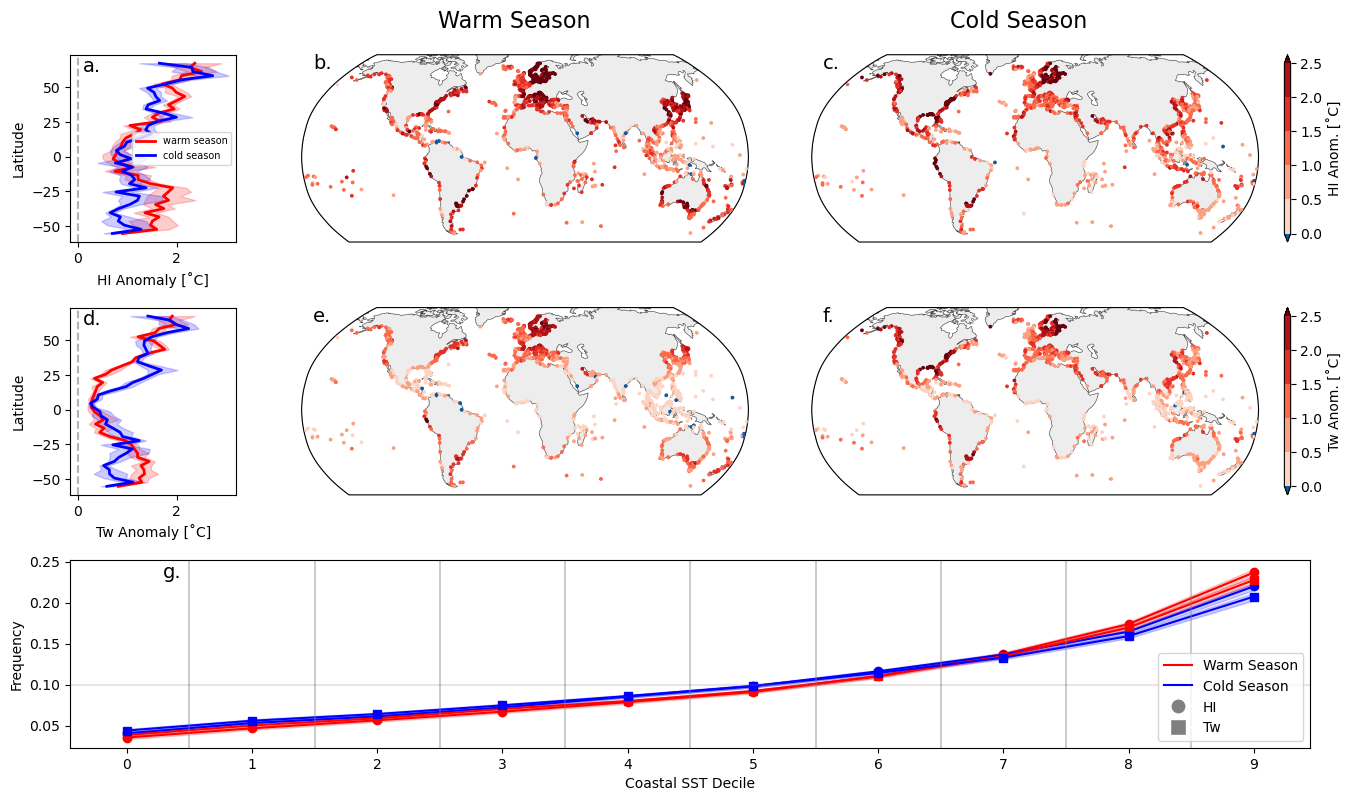

In [16]:
# make A NEW version of the plot with region-stratified bootstrapped means and CI's June 2026

# set cmap
vmin = 0
vmax = 2.5
ncol_i = 6
bounds_i = np.linspace(vmin, vmax, ncol_i)
bluecolors = plt.get_cmap('Blues')(np.linspace(0,1,21))
cols = plt.get_cmap('Reds')(np.linspace(0,1,len(bounds_i)+1))
cmap_i = colors.ListedColormap(cols[1:-1])
cmap_i.set_over(cols[-1])
cmap_i.set_under(bluecolors[-4])
norm_i = mpl.colors.Normalize(vmin=vmin, vmax=vmax)


# setup axes
nrows = 3
ncols = 3
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(nrows=nrows, ncols=ncols, figure=fig, width_ratios=[1, 3, 3]) 
gs.update(wspace=0.1, hspace=0.35)


ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1], projection=ccrs.Robinson())
ax2 = fig.add_subplot(gs[0,2], projection=ccrs.Robinson())
ax3 = fig.add_subplot(gs[1,0], sharex=ax0)
ax4 = fig.add_subplot(gs[1,1], projection=ccrs.Robinson())
ax5 = fig.add_subplot(gs[1,2], projection=ccrs.Robinson())
ax6 = fig.add_subplot(gs[2,:])

## ROW 0
# ax0: lat profiles for HI
ax0.plot(HI_mhw_w_binboot_med, bin_midpoints, color='r', label='warm season', lw=2) # warm-season mean
ax0.fill_betweenx(y=bin_midpoints, x1=HI_mhw_w_binboot_lo, x2=HI_mhw_w_binboot_hi, color='r', alpha=0.2) # warm-season CI

ax0.plot(HI_mhw_c_binboot_med, bin_midpoints, color='b', label='cold season', lw=2) # cold-season mean
ax0.fill_betweenx(y=bin_midpoints, x1=HI_mhw_c_binboot_lo, x2=HI_mhw_c_binboot_hi, color='b', alpha=0.2) # cold-season CI

ax0.set(ylabel='Latitude', xlabel='HI Anomaly [˚C]')
ax0.axvline(color='grey', ls='--', alpha=0.6)
ax0.legend(fontsize=7)

# ax1: map of HI_mhw during warm season
gdf.plot(column='HI_det_mhw_mean_w', ax=ax1, cmap=cmap_i, norm=norm_i, transform=ccrs.PlateCarree(), markersize=3, zorder=10)

# ax2: map of HI_mhw during cold season
gdf.plot(column='HI_det_mhw_mean_c', ax=ax2, cmap=cmap_i, norm=norm_i, transform=ccrs.PlateCarree(), markersize=3, zorder=10)
    
# cbar
sm = plt.cm.ScalarMappable(norm=norm_i, cmap=cmap_i)
sm.set_array([])

cbar = fig.colorbar(sm,  
                    ax=[ax1, ax2],
                    orientation="vertical",
                    extend='both',
                    label="HI Anom. [˚C]",
                    pad=0.025,
                    use_gridspec=True,
                    fraction=0.025, 
                    ticks=bounds_i,
                    aspect=30)


## ROW 1
# ax3: lat profiles for Tw
ax3.plot(tw_mhw_w_binboot_med, bin_midpoints, color='r', label='warm season', lw=2) # warm-season mean
ax3.fill_betweenx(y=bin_midpoints, x1=tw_mhw_w_binboot_lo, x2=tw_mhw_w_binboot_hi, color='r', alpha=0.2) # warm-season CI

ax3.plot(tw_mhw_c_binboot_med, bin_midpoints, color='b', label='cold season', lw=2) # cold-season mean
ax3.fill_betweenx(y=bin_midpoints, x1=tw_mhw_c_binboot_lo, x2=tw_mhw_c_binboot_hi, color='b', alpha=0.2) # cold-season CI

ax3.set(ylabel='Latitude', xlabel='Tw Anomaly [˚C]')
ax3.axvline(color='grey', ls='--', alpha=0.6)

# ax4: Tw_mhw during warm season
gdf.plot(column='Tw_det_mhw_mean_w', ax=ax4, cmap=cmap_i, norm=norm_i, transform=ccrs.PlateCarree(), markersize=3, zorder=10)

# ax5: Tw_mhw during cold season
gdf.plot(column='Tw_det_mhw_mean_c', ax=ax5, cmap=cmap_i, norm=norm_i, transform=ccrs.PlateCarree(), markersize=3, zorder=10)

    
# cbar
sm = plt.cm.ScalarMappable(norm=norm_i, cmap=cmap_i)
sm.set_array([])

cbar = fig.colorbar(sm,  
                    ax=[ax4, ax5],
                    orientation="vertical",
                    extend='both',
                    label="Tw Anom. [˚C]",
                    pad=0.025,
                    use_gridspec=True,
                    fraction=0.025, 
                    ticks=bounds_i,
                    aspect=30)


# Map Cosmetics
for ax in [ax1, ax2, ax4, ax5]:
    ax.add_feature(cartopy.feature.LAND,edgecolor='black',facecolor='gainsboro',linewidth=0.4, alpha=0.5, zorder=0) 
    ax.add_feature(cartopy.feature.OCEAN,edgecolor='black',facecolor='white',linewidth=0.4, alpha=0.5, zorder=0) 



# ax6: <var> extreme vs. SST Decile
xs = np.array(range(10))

ax6.plot(xs, sstbinned_HI90_bootmeds_w, color='r', marker='o')
ax6.fill_between(xs, sstbinned_HI90_locis_w, sstbinned_HI90_hicis_w, color='r', alpha=0.2)

ax6.plot(xs, sstbinned_HI90_bootmeds_c, color='b', marker='o')
ax6.fill_between(xs, sstbinned_HI90_locis_c, sstbinned_HI90_hicis_c, color='b', alpha=0.2)

ax6.plot(xs, sstbinned_tw90_bootmeds_w, color='r', marker='s')
ax6.fill_between(xs, sstbinned_tw90_locis_w, sstbinned_tw90_hicis_w, color='r', alpha=0.2)

ax6.plot(xs, sstbinned_tw90_bootmeds_c, color='b', marker='s')
ax6.fill_between(xs, sstbinned_tw90_locis_c, sstbinned_tw90_hicis_c, color='b', alpha=0.2)
    
ax6.set_xticks(np.arange(0, 10, 1))
ax6.set(title='', xlabel='Coastal SST Decile', ylabel='Frequency')

# vertical line
for l in np.arange(0.5, 8.6, 1):
    ax6.axvline(l, color='gray', alpha=0.4)

ax6.axhline(0.1, color='grey', alpha=0.2)
    
# legend
legend_elements = [Line2D([0], [0], color='r', label='Warm Season'),
                   Line2D([0], [0], color='b', label='Cold Season'),
                   Line2D([0], [0], marker='o', color='w', label='HI',
                          markerfacecolor='grey', markersize=11),
                   Line2D([0], [0], marker='s', color='w', label='Tw',
                          markerfacecolor='grey', markersize=11)]

ax6.legend(handles=legend_elements, loc='lower right')


## subplot labels
letters = ['a', 'b', 'c', 'd', 'e', 'f', 'g']

i = 0
for ax in [ax0, ax1, ax2, ax3, ax4, ax5, ax6]:
    if i==0 or i==3 or i==6:
        ax.text(s='{}.'.format(letters[i]), x=0.075, y=0.91, transform=ax.transAxes, ha='left', fontsize=14)
    else:
        ax.text(s='{}.'.format(letters[i]), x=0.025, y=0.925, transform=ax.transAxes, ha='left', fontsize=14)
    i += 1

fig.text(x=0.355, y=0.91, s='Warm Season', fontsize=16)
fig.text(x=0.675, y=0.91, s='Cold Season', fontsize=16)

# now = datetime.now() # get datetime
# fig.text(0.85, 0.025, 'Created: %s' %now.strftime("%Y-%m-%d %H:%M:%S"), fontsize='x-small', ha='right') # text
# fig.text(0.85, 0.045, script, ha='right', fontsize='x-small')

# SAVE FIGURE
plt.savefig('/home/nsiegert/projects/coastal_sst/plots/grl_resubmission_6.2026/FigSx_coastalsst_grl_6_26_remakeFig1withHITw.png', format='png', bbox_inches='tight')

plt.show()